In [1]:
import sys
sys.path.append('../src')

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

import matplotlib.pyplot as plt
plt.style.core.USER_LIBRARY_PATHS.append('/gscratch/matsulab/utils/ctleelab-mpl-utilities/ctleelab_plothelper')
plt.style.reload_library()

sys.path.append('../../../utils')
from fonts.mpl_fonts import set_arial_font, set_encode_sans_font
# set_arial_font()
set_encode_sans_font()

[mpl_fonts] Using font: Encode Sans Normal
[mpl_fonts] Font dir: /mmfs1/gscratch/matsulab/utils/fonts


In [23]:
## To reload

import importlib
import pinn.plot as plot
import data_generation.preprocess as preprocess
import pinn.utils as utils
import pinn.analysis as analysis
import fonts.mpl_fonts as mpl_fonts

importlib.reload(plot)
importlib.reload(utils)
importlib.reload(preprocess)
importlib.reload(analysis)
importlib.reload(mpl_fonts)

<module 'fonts.mpl_fonts' from '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/notebooks/../../../utils/fonts/mpl_fonts.py'>

In [2]:
## Loss Progress
## Load data

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.utils import load_loss_history_dir, concat_histories
from pinn.plot import plot_loss_panels

# ==== Parameters =====
lambda_1 = 100000
lambda_2_list = [1]
lambda_3 = 100000
# shape_list = ["biconcave"]
shape_list = ["czii_gl_1"]
steps_series = list(range(0, 10001, 100))

additive = 0.15
missing  = 0.6
str_add  = str(additive).replace('.', '')
str_miss = str(missing).replace('.', '')
version  = "data_0123"


assembled_loss = {}

for shape in shape_list:
    assembled_loss[shape] = {}
    # root_dir = f"../outputs/logs/{shape}/{version}/a{str_add}_m{str_miss}"
    root_dir = f"../outputs/logs/{shape}"

    for lambda_2 in lambda_2_list:
        print(f"Loading {shape}, {lambda_2}...")
        
        base_dir = os.path.abspath(f"{root_dir}/lambda_{lambda_1}_0_{lambda_3}")
        cont_dir = os.path.abspath(f"{root_dir}/lambda_{lambda_1}_{lambda_2}_{lambda_3}_cont")

        # read checkpoints that exist on disk
        steps_base_actual = list(range(0, 10001, 100))     # checkpoint_0..10000
        steps_cont_actual = list(range(0, 10001, 100))     # checkpoint_0..10000 in *_cont

        hist_base = load_loss_history_dir(base_dir, steps_base_actual, step_offset=0)
        hist_cont = load_loss_history_dir(cont_dir, steps_cont_actual, step_offset=10000)

        assembled_loss[shape][lambda_2] = concat_histories(hist_base, hist_cont)


# fig, axes = plot_loss_panels(assembled_loss, shape_list, lambda_2_list)
# plt.show(fig)

Loading czii_gl_1, 1...


[mpl_fonts] Using font: Encode Sans Normal
[mpl_fonts] Font dir: /mmfs1/gscratch/matsulab/utils/fonts


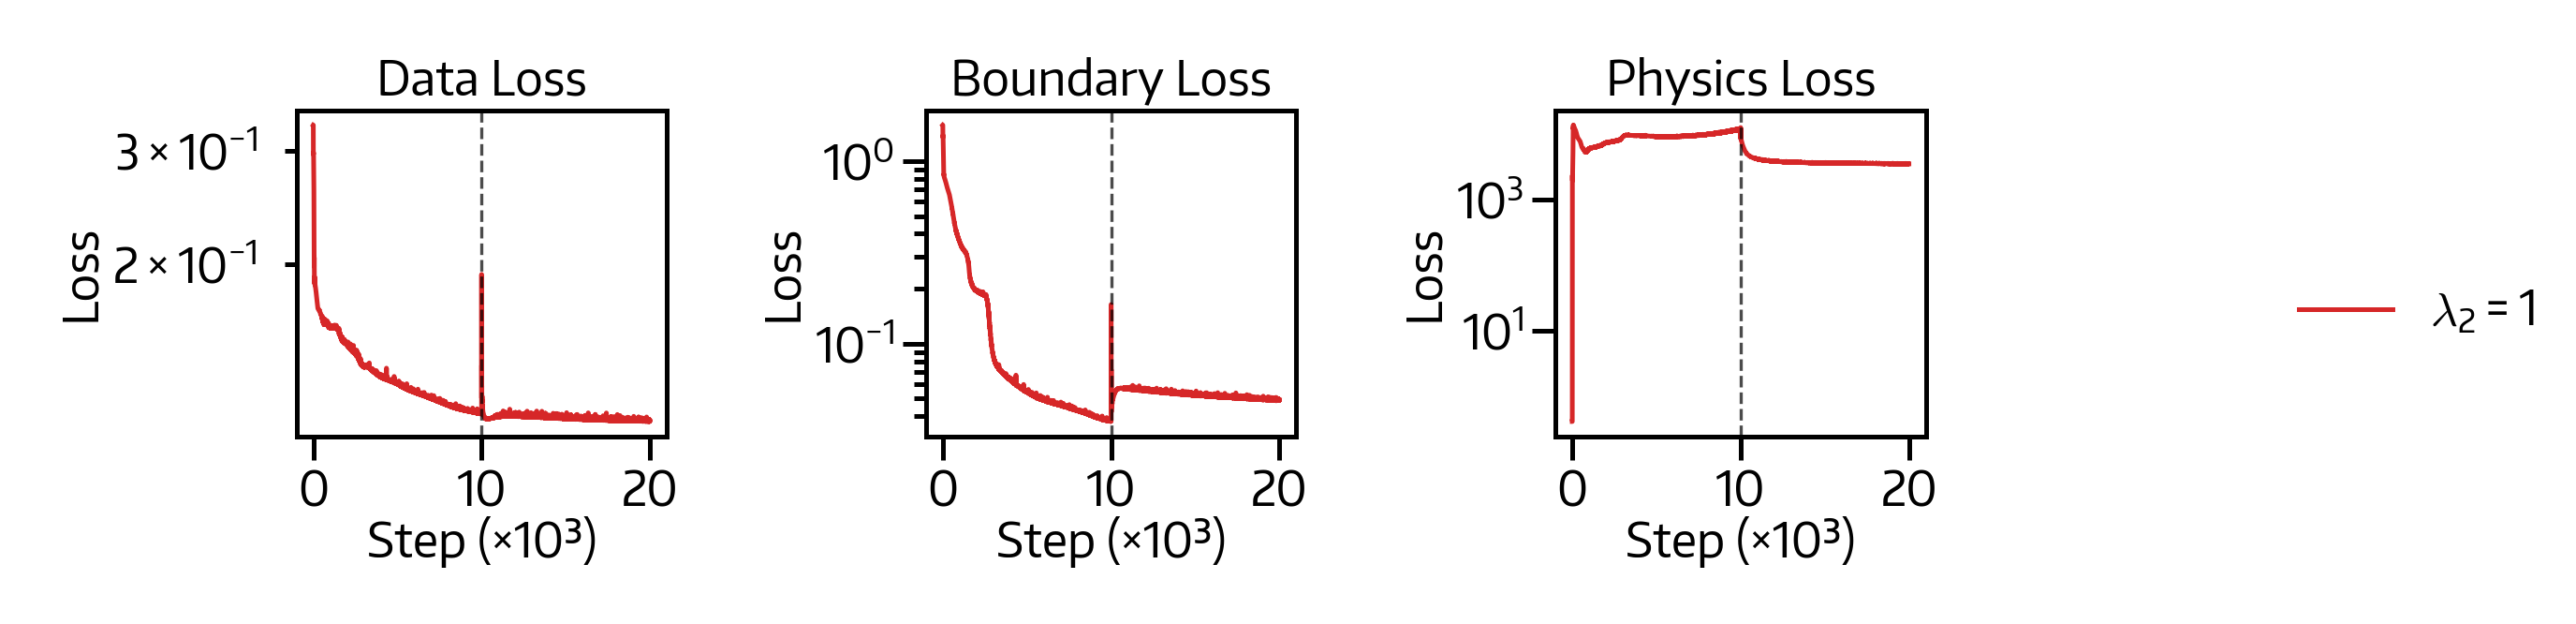

In [3]:
## FIGURE 2C (Loss Progress)
## Plot figures

linewidth = 0.6
logscale_keys = ["data_loss", "sign_loss", "phys_loss", "total_loss"]
show_legend = True

color_map_lambda2 = {
    0:  "tab:blue",
    10: "tab:red",
    1:  "tab:red",
}

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):
    set_encode_sans_font()

    loss_keys   = ["data_loss", "sign_loss", "phys_loss"]
    loss_titles = ["Data Loss", "Boundary Loss", "Physics Loss"]

    # --- color: depends only on λ2 ---
    if "color_map_lambda2" not in locals() or color_map_lambda2 is None:
        default_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
        color_map_lambda2 = {
            lam2: default_cycle[i % len(default_cycle)]
            for i, lam2 in enumerate(lambda_2_list)
        }

    fig, axes = plt.subplots(1, 3, figsize=(5.0, 1), sharex=True)

    handles_by_lambda2 = {}

    for ax, key, title in zip(axes, loss_keys, loss_titles):

        for lambda_2 in lambda_2_list:
            hist = assembled_loss[shape][lambda_2]

            x = np.asarray(hist["step"]) / 1000.0
            y = np.asarray(hist[key])

            h, = ax.plot(
                x, y,
                linestyle="-",
                color=color_map_lambda2[lambda_2],
                linewidth=linewidth,
            )

            # collect one legend entry per λ2
            handles_by_lambda2.setdefault(lambda_2, h)

        ax.set_title(title, pad=2)
        ax.set_xlabel("Step (×10³)", labelpad=0)
        ax.set_ylabel("Loss")
        ax.grid(False)

        if key in logscale_keys:
            ax.set_yscale("log")

        ax.axvline(10, linestyle="--", color="k", linewidth=0.4, alpha=0.7)
        ax.set_xticks([0, 10, 20])

    if show_legend:
        legend_handles = [handles_by_lambda2[lam2] for lam2 in lambda_2_list]
        legend_labels  = [fr"$\lambda_2={lam2}$" for lam2 in lambda_2_list]

        fig.legend(
            legend_handles,
            legend_labels,
            loc="center right",
            frameon=False,
            labelspacing=0.0,
        )

    fig.subplots_adjust(wspace=0.7, left=0.2, right=0.78, bottom=0.3)
    # fig.savefig(f"../outputs/figs/v_0127/synth_loss_{shape}.pdf", dpi=600, bbox_inches=None)
    fig.savefig(f"../outputs/figs/v_0127/exp_loss_{shape}_.pdf", dpi=600, bbox_inches=None)
    plt.show()


[mpl_fonts] Using font: Encode Sans Normal
[mpl_fonts] Font dir: /mmfs1/gscratch/matsulab/utils/fonts


/tmp/ipykernel_63988/901531898.py:73: UserWarning: Glyph 963 (\N{GREEK SMALL LETTER SIGMA}) missing from font(s) Encode Sans Normal.
  fig.savefig(f"../outputs/figs/v_0127/synth_curve_a{str_add}_m{str_miss}_{shape}_.pdf", bbox_inches="tight")


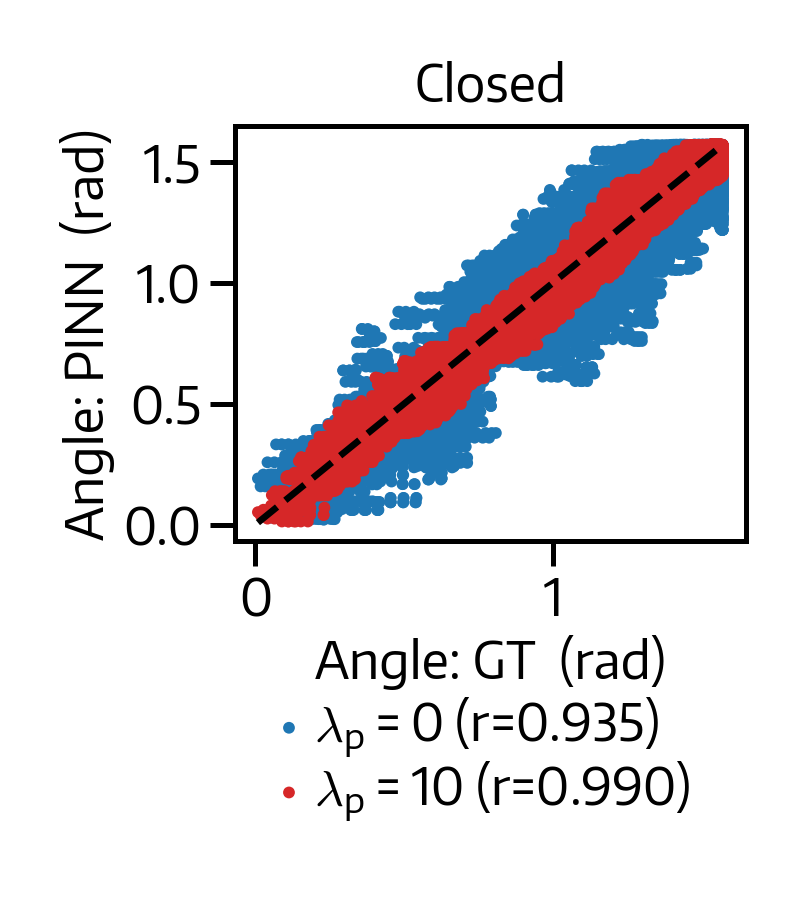

/gscratch/matsulab/envs/pinn-env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 963 (\N{GREEK SMALL LETTER SIGMA}) missing from font(s) Encode Sans Normal.
  fig.canvas.print_figure(bytes_io, **kw)


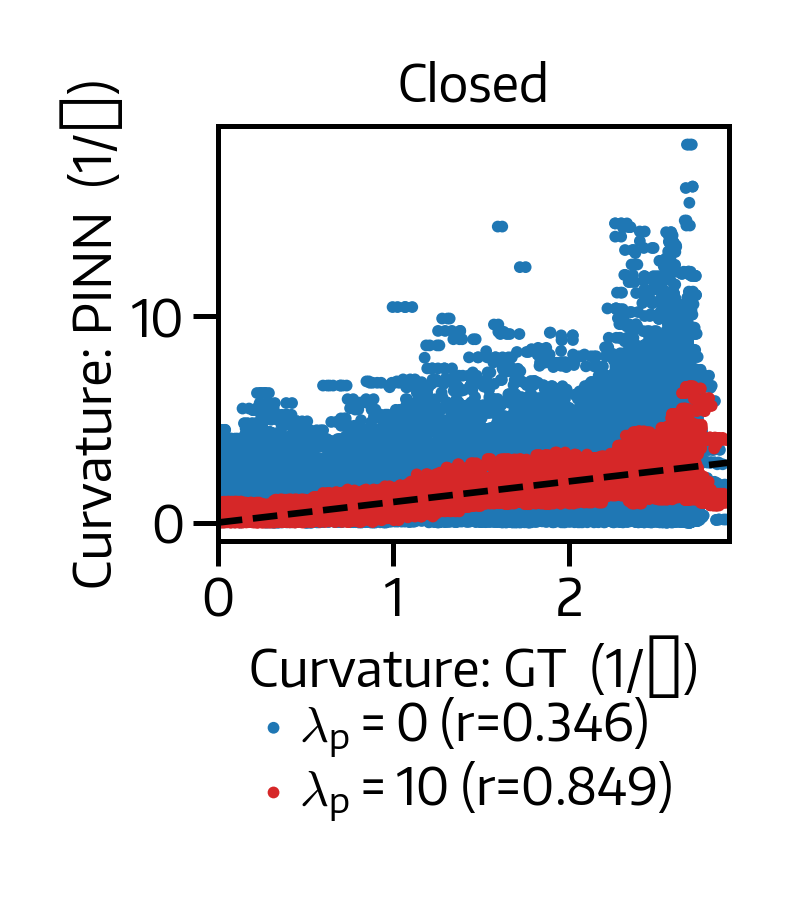

In [33]:
# FIGURE 2F (Quantification of Normal and Curvatures)

from pinn.normal_curves import load_mesh_npz, match_and_plot_two_data
import numpy as np

# ==== Parameters =====
lambda_1 = 100000
lambda_2_list = [0, 10]
lambda_3 = 100000
shape = "biconcave"
step = 10000
additive = 0.15
missing  = 0.6
str_add  = str(additive).replace('.', '')
str_miss = str(missing).replace('.', '')
version  = "data_0123"

SHAPE_TITLE_MAP = {
    "biconcave": "Closed",
    "bud_04": "Open",
    "multi": "Multiple",
}

# ==== Load npz data =====
# GROUND TRUTH
npz_path = f"../data/synthetic/gt/gt_refined_{shape}.npz"
verts_gt, faces_gt, norms_gt, curvs_gt = load_mesh_npz(npz_path)
curvs_gt = np.abs(curvs_gt)
# theta_gt = np.arccos(norms_gt @ (0,0,1))
theta_gt = np.arccos(np.abs(norms_gt @ (0,0,1)))

# PINN RESULTS
verts_pf = {}; curvs_pf = {}; theta_pf = {}
for lambda_2 in lambda_2_list:
    checkpoint_dir = f"../outputs/logs/{shape}/{version}/a{str_add}_m{str_miss}/lambda_{lambda_1}_{lambda_2}_{lambda_3}_cont"
    npz_path = f"{checkpoint_dir}/verts_{step}.npz"
    verts, faces, norms, curvs = load_mesh_npz(npz_path)
    curvs = np.abs(curvs) * 0.5
    # theta = np.arccos(norms @ (0,0,1))
    theta = np.arccos(np.abs(norms @ (0,0,1)))
    verts_pf[lambda_2] = verts; curvs_pf[lambda_2] = curvs; theta_pf[lambda_2] = theta
    
title_shape = SHAPE_TITLE_MAP.get(shape, shape)

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):
    set_encode_sans_font()
    fig = match_and_plot_two_data(verts_gt, theta_gt, 
                            verts_pf[0], theta_pf[0], 
                            verts_pf[10], theta_pf[10], 
                            # xlim=(0,1),
                            xlabel="Angle: GT  (rad)",
                            ylabel="Angle: PINN  (rad)",
                            labels=(r"$\lambda_p=0$", r"$\lambda_p=10$"),
                            title=f"{title_shape}",
                            figsize=(1.1,0.9),
                            colors=("tab:blue", "tab:red"),
                           )
    fig.savefig(f"../outputs/figs/v_0127/synth_normal_a{str_add}_m{str_miss}_{shape}_.pdf", bbox_inches="tight")
    
    fig = match_and_plot_two_data(verts_gt, curvs_gt, 
                            verts_pf[0], curvs_pf[0], 
                            verts_pf[10], curvs_pf[10], 
                            # xlim=(0,5),
                            xlim = (0, np.max(curvs_gt)),
                            xlabel="Curvature: GT  (1/σ)",
                            ylabel="Curvature: PINN  (1/σ)",
                            labels=(r"$\lambda_p=0$", r"$\lambda_p=10$"),
                            title=f"{title_shape}",
                            figsize=(1.1,0.9),
                            colors=("tab:blue", "tab:red"),
                           )
    fig.savefig(f"../outputs/figs/v_0127/synth_curve_a{str_add}_m{str_miss}_{shape}_.pdf", bbox_inches="tight")
    plt.show()

In [50]:
## Make video of progress

# Make a combined movie

import matplotlib.pyplot as plt
import os
from pinn.plot import visualize_phase
from flax.training import checkpoints
import imageio
import re
from tqdm.auto import tqdm 

GRID_SIZE = 128
lambda_1 = 100000
# lambda_2_list = [0, 10]
lambda_2 = 1
lamdba_3 = 100000
shape = "czii_gl_1"
version = "0123"
step_max = 10000
epsilon = 0.05
additive = 0.15
missing  = 0.6
str_add  = str(additive).replace('.', '')
str_miss = str(missing).replace('.', '')
steps_to_visualize = list(range(0, step_max+1, 100))
slice_index = 76
axis = "x"
fps = 24

# log_dir = os.path.abspath(f"../outputs/logs/{shape}/data_{version}/a{str_add}_m{str_miss}/")
log_dir = os.path.abspath(f"../outputs/logs/{shape}/")
frame_dir = os.path.join(log_dir, f"progress")

def save_frame_combined(step, ckpt_1, ckpt_2, save_dir="frames", grid_size=64, slice_index=32, axis="z", show_step=True):
    set_encode_sans_font()
    fig = plt.figure(figsize=(8, 4))
    ax1 = fig.add_subplot(121)
    ax2 = fig.add_subplot(122)
    visualize_phase(ax1, epsilon=epsilon, checkpoint=ckpt_1, component="phi",
                        grid_size=GRID_SIZE, slice_index=slice_index, axis=axis, no_label=True, vmin=-1, vmax=1)
    visualize_phase(ax2, epsilon=epsilon, checkpoint=ckpt_2, component="phi",
                        grid_size=GRID_SIZE, slice_index=slice_index, axis=axis, no_label=True, vmin=-1, vmax=1)
    if show_step:
        fig.text(0.5, 0.02, f"Step: {step}", ha="center", va="bottom", fontsize=24,)
    os.makedirs(save_dir, exist_ok=True)
    filename = os.path.join(save_dir, f"frame_{step:06d}.png")
    plt.savefig(filename, dpi=150)
    plt.close(fig)

def save_frame_single(step, ckpt_1, save_dir="frames", grid_size=64, slice_index=32, axis="z", show_step=True):
    set_encode_sans_font()
    fig = plt.figure(figsize=(4, 4))
    ax1 = fig.add_subplot(111)
    visualize_phase(ax1, epsilon=epsilon, checkpoint=ckpt_1, component="phi",
                        grid_size=GRID_SIZE, slice_index=slice_index, axis=axis, no_label=True, vmin=-1, vmax=1)
    if show_step:
        fig.text(0.5, 0.02, f"Step: {step}", ha="center", va="bottom", fontsize=24,)
    os.makedirs(save_dir, exist_ok=True)
    filename = os.path.join(save_dir, f"frame_{step:06d}.png")
    ax1.set_ylim(ax1.get_ylim()[::-1]) # flip y
    plt.savefig(filename, dpi=150)
    plt.close(fig)

def make_movie_from_frames(
    frame_dir="frames",
    output="movie.mp4",
    fps=12,
    start=0,
    end=40000,
    stride=200,
):
    pattern = re.compile(r"frame_(\d+)\.png$")
    frames = []

    for fname in os.listdir(frame_dir):
        m = pattern.match(fname)
        if not m:
            continue

        index = int(m.group(1))
        if start <= index <= end and (index - start) % stride == 0:
            frames.append((index, os.path.join(frame_dir, fname)))

    frames.sort(key=lambda x: x[0])

    with imageio.get_writer(output, fps=fps) as writer:
        for _, frame_path in frames:
            image = imageio.imread(frame_path)
            writer.append_data(image)

print("Making Movie...")
for step in tqdm(steps_to_visualize, total=len(steps_to_visualize)):

    # FIRST HALF
    ckpt_path = os.path.join(log_dir, f"lambda_{lambda_1}_0_{lambda_3}/checkpoint_{step}")
    ckpt_data = checkpoints.restore_checkpoint(ckpt_dir=ckpt_path, target=None)
    ckpt_1 = ckpt_data
    ckpt_2 = ckpt_data
    # save_frame_combined(step, ckpt_1, ckpt_2, save_dir=frame_dir, grid_size=GRID_SIZE, slice_index=slice_index, axis=axis)
    save_frame_single(step, ckpt_1, save_dir=frame_dir, grid_size=GRID_SIZE, slice_index=slice_index, axis=axis)

    # SECOND HALF
    # ckpt_data = {}
    # for lambda_2 in lambda_2_list:
    #     ckpt_path = os.path.join(log_dir, f"lambda_{lambda_1}_{lambda_2}_{lambda_3}_cont/checkpoint_{step}")
    #     ckpt_data[lambda_2] = checkpoints.restore_checkpoint(ckpt_dir=ckpt_path, target=None)
    # lam2_1, lam2_2 = lambda_2_list
    # ckpt_1 = ckpt_data[lam2_1]
    # ckpt_2 = ckpt_data[lam2_2]

    ckpt_path = os.path.join(log_dir, f"lambda_{lambda_1}_{lambda_2}_{lambda_3}_cont/checkpoint_{step}")
    ckpt_data = checkpoints.restore_checkpoint(ckpt_dir=ckpt_path, target=None)

    # save_frame_combined(step+10000, ckpt_1, ckpt_2, save_dir=frame_dir, grid_size=GRID_SIZE, slice_index=slice_index, axis=axis)
    save_frame_single(step+10000, ckpt_data, save_dir=frame_dir, grid_size=GRID_SIZE, slice_index=slice_index, axis=axis)

output=os.path.abspath(f"{frame_dir}/phase_progress_{shape}.mp4")
make_movie_from_frames(frame_dir=frame_dir, output=output, start=0, end=40000, fps=fps, stride=200)

Making Movie...


  0%|          | 0/101 [00:00<?, ?it/s]

[mpl_fonts] Using font: Encode Sans Normal
[mpl_fonts] Font dir: /mmfs1/gscratch/matsulab/utils/fonts
[mpl_fonts] Using font: Encode Sans Normal
[mpl_fonts] Font dir: /mmfs1/gscratch/matsulab/utils/fonts
[mpl_fonts] Using font: Encode Sans Normal
[mpl_fonts] Font dir: /mmfs1/gscratch/matsulab/utils/fonts
[mpl_fonts] Using font: Encode Sans Normal
[mpl_fonts] Font dir: /mmfs1/gscratch/matsulab/utils/fonts
[mpl_fonts] Using font: Encode Sans Normal
[mpl_fonts] Font dir: /mmfs1/gscratch/matsulab/utils/fonts
[mpl_fonts] Using font: Encode Sans Normal
[mpl_fonts] Font dir: /mmfs1/gscratch/matsulab/utils/fonts
[mpl_fonts] Using font: Encode Sans Normal
[mpl_fonts] Font dir: /mmfs1/gscratch/matsulab/utils/fonts
[mpl_fonts] Using font: Encode Sans Normal
[mpl_fonts] Font dir: /mmfs1/gscratch/matsulab/utils/fonts
[mpl_fonts] Using font: Encode Sans Normal
[mpl_fonts] Font dir: /mmfs1/gscratch/matsulab/utils/fonts
[mpl_fonts] Using font: Encode Sans Normal
[mpl_fonts] Font dir: /mmfs1/gscratch/m

/tmp/ipykernel_63988/3518074010.py:89: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(frame_path)


[mpl_fonts] Using font: Encode Sans Normal
[mpl_fonts] Font dir: /mmfs1/gscratch/matsulab/utils/fonts


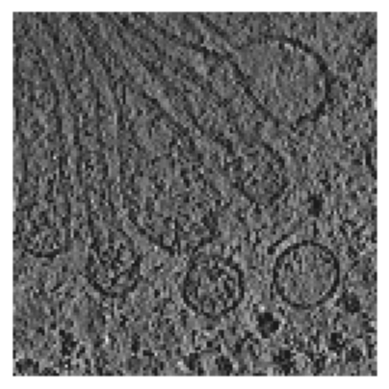

In [12]:
import mrcfile
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

shape = "czii_gl_1"
mrc_path = f"../data/experimental/downsampled/{shape}.mrc"
# cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

with mrcfile.open(mrc_path, permissive=True) as mrc:
    data = mrc.data.copy()   # shape usually (Z, Y, X)
z = 76

custom_gray = LinearSegmentedColormap.from_list(
    'custom_gray', ['#f0f0f0', '#777777']  # light gray to dark gray
)
plt.imshow(data[z], cmap="gray_r", alpha=0.9)
# plt.imshow(data[z], cmap=custom_gray)
plt.axis("off")
plt.savefig(f"../outputs/figs/v_0127/mrc_{shape}.png", bbox_inches="tight", dpi=600)
plt.show()
